# Speech Audio Denoising Using a Pretrained Model

### Install & Import Required Libraries

In [17]:
!pip install  speechbrain transformers datasets librosa soundfile matplotlib torch

In [18]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import torch

### Load Noisy Audio

In [30]:
audio_path = "audio_noise.wav"
signal, sr = librosa.load(audio_path, sr=16000)

### Load a Pretrained Model

In [31]:
from speechbrain.pretrained import SpectralMaskEnhancement
enhancer = SpectralMaskEnhancement.from_hparams(
    source="speechbrain/metricgan-plus-voicebank",
    savedir="pretrained_model"
)

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/content/pretrained_model/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch enhance_model.ckpt: Using symlink found at '/content/pretrained_model/enhance_model.ckpt'
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: enhance_model


### Run Inference

In [32]:
enhanced = enhancer.enhance_file(audio_path)

### Save the Denoised Audio Files

In [33]:
sf.write(
    "denoised.wav",
    enhanced.squeeze().cpu().numpy(),
    16000
)

### Load Denoised Audio

In [41]:
signal_clean, sr_clean = librosa.load(
    "denoised.wav",
    sr=16000
)

### WaveForm Comparison

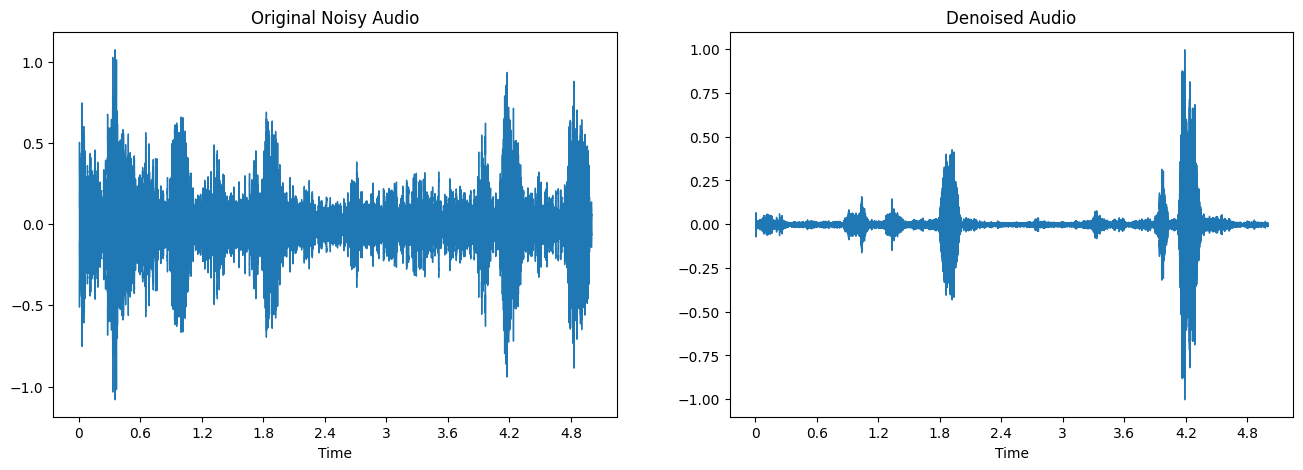

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
librosa.display.waveshow(signal, sr=sr, ax=ax[0])
ax[0].set_title("Original Noisy Audio")
librosa.display.waveshow(signal_clean, sr=sr_clean, ax=ax[1])
ax[1].set_title("Denoised Audio")
plt.show()

### Spectrogram Comparison

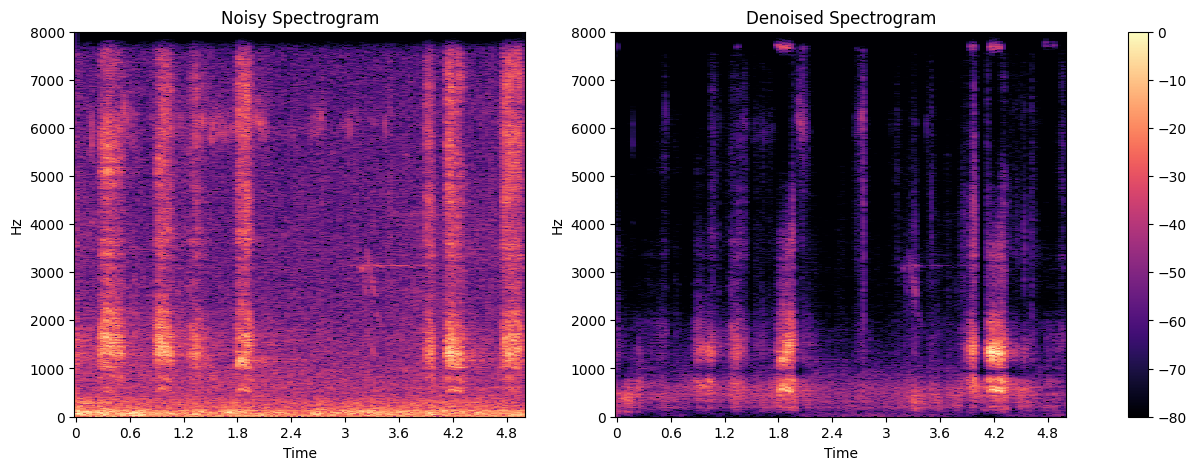

In [44]:
D_noisy = librosa.amplitude_to_db(
    np.abs(librosa.stft(y)),
    ref=np.max
)
D_clean = librosa.amplitude_to_db(
    np.abs(librosa.stft(y_clean)),
    ref=np.max
)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
img1 = librosa.display.specshow(
    D_noisy,
    sr=sr,
    x_axis='time',
    y_axis='hz',
    ax=ax[0]
)
ax[0].set_title("Noisy Spectrogram")
img2 = librosa.display.specshow(
    D_clean,
    sr=sr_clean,
    x_axis='time',
    y_axis='hz',
    ax=ax[1]
)
ax[1].set_title("Denoised Spectrogram")
fig.colorbar(img2, ax=ax)
plt.show()